In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


#**1. Data Preparation:**

In [13]:
df =  pd.read_excel('US Superstore data.xls')
df.isnull().sum()
df.info()
df.head()

# missing = df.isna().sum().sort_values(ascending=False)
# display(missing.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.replace(' ', '').str.upper().str.strip()
print("String cleaning applied to all object-type columns.")

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# print(df.select_dtypes(include='object').columns)
df.info()

String cleaning applied to all object-type columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 

#**Data Visualization with Matplotlib:**

##Create an interactive line chart to show sales trends over the years.


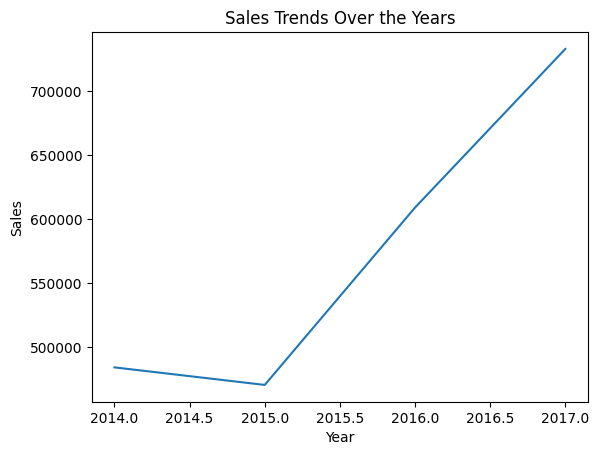

In [11]:
plt.plot(df.groupby(df['Order Date'].dt.year)['Sales'].sum())
plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Sales Trends Over the Years')
plt.show()

From 2015 to 2017, we notice a strong upward trajectory, with sales climbing from around \$450,000 to over $750,000, indicating recovery and growth.

##Build an interactive map to visualize sales distribution by country.


# Task
Aggregate the sales by country from the `df` DataFrame, and then create an interactive choropleth map using Plotly Express to visualize the sales distribution across different countries. The map should display the total sales for each country, include a clear title, a suitable color scale, and provide sales values on hover. Finally, display the generated map and highlight any insights from the sales distribution.

In [22]:
country_sales = df.groupby('Country')['Sales'].sum().reset_index()
print(country_sales.head(20))

         Country         Sales
0  United States  2.297201e+06


**Reasoning**:
Now that `country_sales` has been created and `plotly.express` has been imported, the next step is to create the interactive choropleth map to visualize sales distribution by country as specified in the main task. This will involve using `px.choropleth` with the `country_sales` DataFrame, mapping 'Country' to locations and 'Sales' to color, and configuring the map for display.



In [23]:
fig = px.choropleth(
    country_sales,
    locations='Country',
    locationmode='country names',
    color='Sales',
    hover_name='Country',
    hover_data={'Sales': True},
    color_continuous_scale='Plasma',
    title='Sales Distribution by Country'
)
fig.show()
print("Choropleth map showing sales distribution by country has been generated.")

Choropleth map showing sales distribution by country has been generated.


In [28]:
# from geopy.geocoders import Nominatim
# import time

# geolocator = Nominatim(user_agent="geoapi")

# # Create new columns for lat/lon
# df['Latitude'] = None
# df['Longitude'] = None

# for i, row in df.iterrows():
#     location = geolocator.geocode(f"{row['City']}, {row['Country']}")
#     if location:
#         df.at[i, 'Latitude'] = location.latitude
#         df.at[i, 'Longitude'] = location.longitude
#     time.sleep(1)  # avoid hitting API rate limits

# fig = px.scatter_geo(
#     df,
#     lat='Latitude',
#     lon='Longitude',
#     size='Sales',
#     hover_name='City',
#     color='Sales',
#     color_continuous_scale='Plasma',
#     title='Sales Distribution by City'
# )
# fig.show()


#**Data Visualization with Seaborn:**
##Use Seaborn to generate a bar chart showing top 10 products by sales.

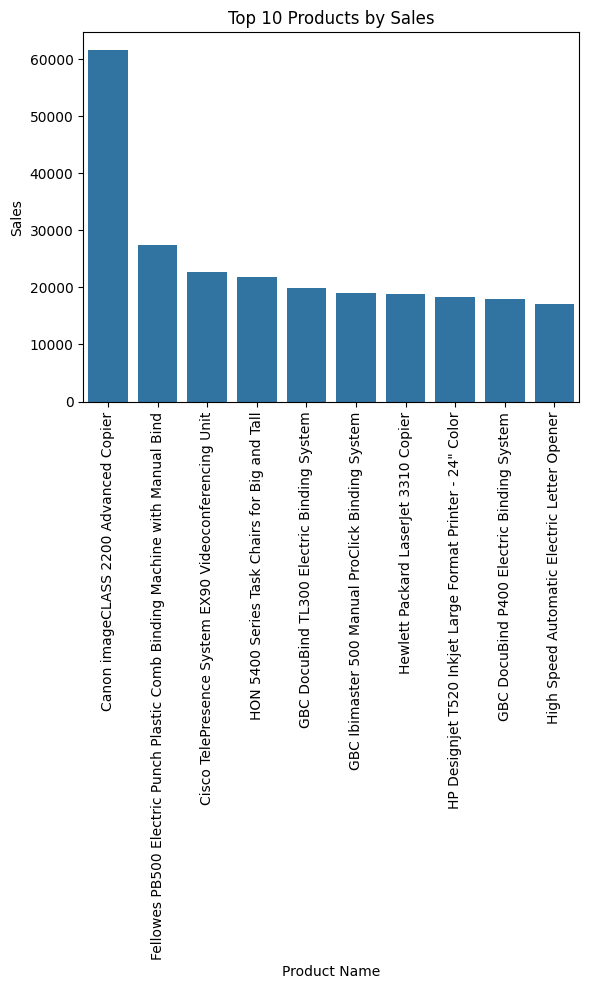

In [26]:
sns.barplot(x=df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).index,
            y=df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).values)
plt.xlabel('Product Name')
plt.ylabel('Sales')
plt.title('Top 10 Products by Sales')
plt.xticks(rotation=90)
plt.show()

**Canon ImageCLASS 2200 Advanced Copier** dominates with sales nearing $65,000, significantly ahead of the second-place product. while the remaining products show a gradual decline in sales.

##Create a scatter plot to analyze the relationship between profit and discount.

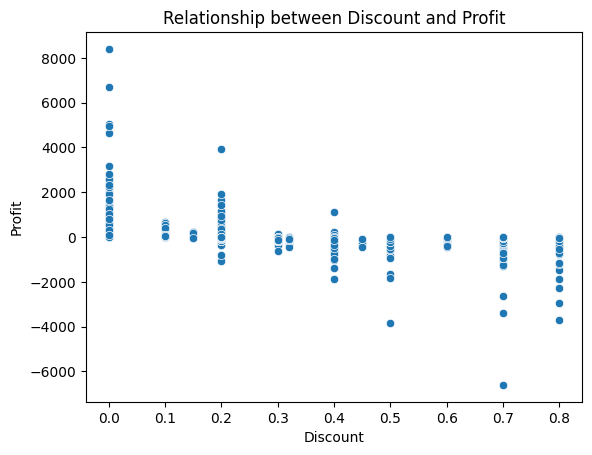

In [27]:
sns.scatterplot(x=df['Discount'], y=df['Profit'])
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Relationship between Discount and Profit')
plt.show()

* We have a negative correlation. As discounts increase, profits tend to decrease. This suggests that aggressive (< 0.3) discounting often erodes profit margins.


* At lower discount levels (0.0–0.2), profit outcomes are more varied—some transactions yield high profits, while others still result in losses. This implies that discount alone isn't the sole driver of profitability.

#**Comparative Analysis:**
##Compare the insights gained from Matplotlib and Seaborn visualizations.



We Use Matplotlib when we need complete control over plot details and when creating highly customized visualizations.

Seaborn used when we want to quickly explore data relationships and create visually appealing statistical graphics with less effort.

##Document your observations about the ease of use and effectiveness of both tools.

Both libraries have their strengths and can be used complementarily. For instance, one might use Seaborn for initial exploratory analysis and then Matplotlib for fine-tuning the final visualizations.

* Matplotlib is best suited for users who require complete control over their visualizations and are willing to invest time in learning its intricacies. It's ideal for creating customized graphics for detailed analyses.

* Seaborn is more effective for quick, insightful visualizations, especially in exploratory data analysis. Its user-friendly design and built-in statistical functions make it a preferred choice for those looking to visualize data with minimal effort.